## Time series forecasting with tensorflow

## Get data

In [1]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv

--2026-04-20 17:21:23--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 178509 (174K) [text/plain]
Saving to: ‘BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv’

BTC_USD_2013-10-01_ 100%[===================>] 174.33K  --.-KB/s    in 0.02s   

2026-04-20 17:21:23 (7.43 MB/s) - ‘BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv’ saved [178509/178509]



## Import time series with pandas

In [2]:
import pandas as pd
df = pd.read_csv("/content/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv", parse_dates=["Date"], index_col=["Date"])
df.head()

,Currency,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
Date,,,,,
2013-10-01,BTC,123.65499,124.30466,124.75166,122.56349
2013-10-02,BTC,125.45500,123.65499,125.75850,123.63383
2013-10-03,BTC,108.58483,125.45500,125.66566,83.32833
2013-10-04,BTC,118.67466,108.58483,118.67500,107.05816
2013-10-05,BTC,121.33866,118.67466,121.93633,118.00566


In [3]:
bitcoin_price = pd.DataFrame(df["Closing Price (USD)"]).rename(columns={"Closing Price (USD)": "price"})
bitcoin_price.head()

,price
Date,
2013-10-01,123.65499
2013-10-02,125.45500
2013-10-03,108.58483
2013-10-04,118.67466
2013-10-05,121.33866


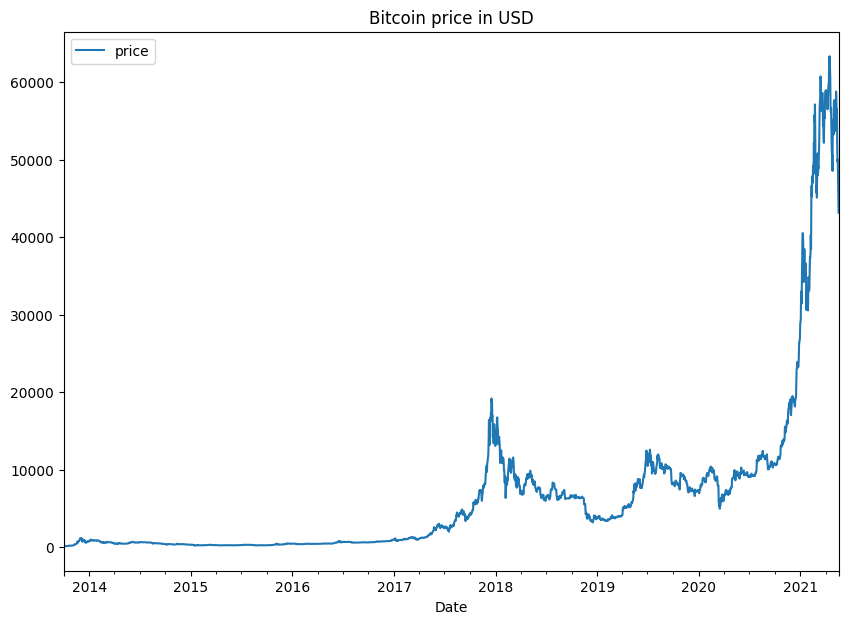

In [4]:
import matplotlib.pyplot as plt
bitcoin_price.plot(figsize=(10, 7), title="Bitcoin price in USD")
plt.show()

## Import series with Python's CSV module

In [5]:
import csv
from datetime import datetime

timesteps = []
btc_price = []
with open("/content/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv", "r") as f:
  csv_reader = csv.reader(f, delimiter=",")
  next(csv_reader)
  for line in csv_reader:
    timesteps.append(datetime.strptime(line[1], "%Y-%m-%d"))
    btc_price.append(float(line[2]))

timesteps[:10],btc_price[:10]

([datetime.datetime(2013, 10, 1, 0, 0),
  datetime.datetime(2013, 10, 2, 0, 0),
  datetime.datetime(2013, 10, 3, 0, 0),
  datetime.datetime(2013, 10, 4, 0, 0),
  datetime.datetime(2013, 10, 5, 0, 0),
  datetime.datetime(2013, 10, 6, 0, 0),
  datetime.datetime(2013, 10, 7, 0, 0),
  datetime.datetime(2013, 10, 8, 0, 0),
  datetime.datetime(2013, 10, 9, 0, 0),
  datetime.datetime(2013, 10, 10, 0, 0)],
 [123.65499,
  125.455,
  108.58483,
  118.67466,
  121.33866,
  120.65533,
  121.795,
  123.033,
  124.049,
  125.96116])

Text(0.5, 1.0, 'Bitcoin price in USD')

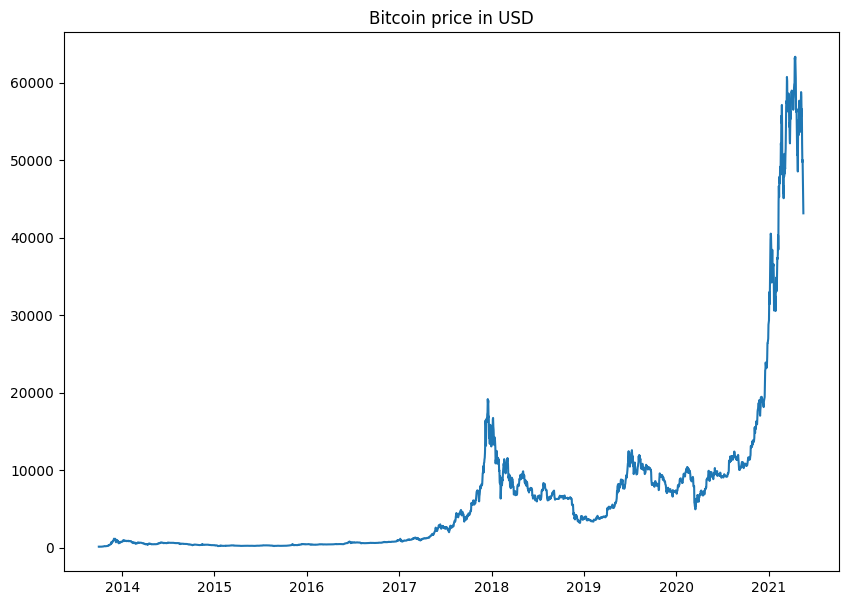

In [6]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 7))
plt.plot(timesteps, btc_price)
plt.title("Bitcoin price in USD")

In [7]:
bitcoin_prices = pd.DataFrame(df["Closing Price (USD)"]).rename(columns={"Closing Price (USD)": "Price"})
bitcoin_prices.head()

,Price
Date,
2013-10-01,123.65499
2013-10-02,125.45500
2013-10-03,108.58483
2013-10-04,118.67466
2013-10-05,121.33866


In [8]:
timesteps = bitcoin_prices.index.to_numpy()
prices = bitcoin_prices["Price"].to_numpy()

timesteps[:10], prices[:10]

(array(['2013-10-01T00:00:00.000000000', '2013-10-02T00:00:00.000000000',
        '2013-10-03T00:00:00.000000000', '2013-10-04T00:00:00.000000000',
        '2013-10-05T00:00:00.000000000', '2013-10-06T00:00:00.000000000',
        '2013-10-07T00:00:00.000000000', '2013-10-08T00:00:00.000000000',
        '2013-10-09T00:00:00.000000000', '2013-10-10T00:00:00.000000000'],
       dtype='datetime64[ns]'),
 array([123.65499, 125.455  , 108.58483, 118.67466, 121.33866, 120.65533,
        121.795  , 123.033  , 124.049  , 125.96116]))

In [9]:
# Create train and test splits the right way for time series data
split_size = int(0.8 * len(prices)) # 80% train, 20% test

# Create train data splits (everything before the split)
X_train, y_train = timesteps[:split_size], prices[:split_size]

# Create test data splits (everything after the split)
X_test, y_test = timesteps[split_size:], prices[split_size:]

len(X_train), len(X_test), len(y_train), len(y_test)

(2229, 558, 2229, 558)

In [10]:


# Create a function to plot time series data
def plot_time_series(timesteps, values, format='.', start=0, end=None, label=None):
  """
  Plots a timesteps (a series of points in time) against values (a series of values across timesteps).

  Parameters
  ---------
  timesteps : array of timesteps
  values : array of values across time
  format : style of plot, default "."
  start : where to start the plot (setting a value will index from start of timesteps & values)
  end : where to end the plot (setting a value will index from end of timesteps & values)
  label : label to show on plot of values
  """
  # Plot the series
  plt.plot(timesteps[start:end], values[start:end], format, label=label)
  plt.xlabel("Time")
  plt.ylabel("BTC Price")
  if label:
    plt.legend(fontsize=14) # make label bigger
  plt.grid(True)

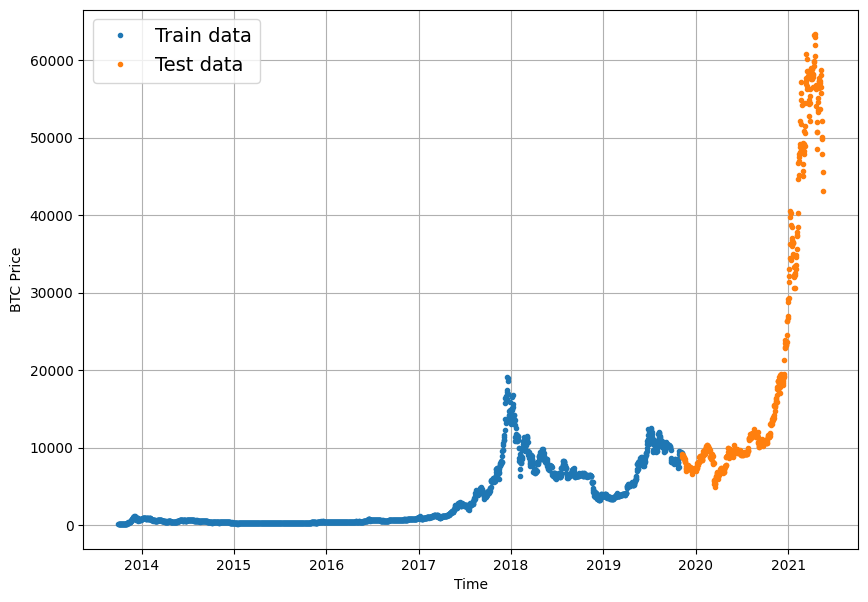

In [11]:
# Try out our plotting function
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Train data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")

In [12]:
# Create a naïve forecast
naive_forecast = y_test[:-1] # Naïve forecast equals every value excluding the last value
naive_forecast[:10], naive_forecast[-10:] # View frist 10 and last 10

(array([9226.48582088, 8794.35864452, 8798.04205463, 9081.18687849,
        8711.53433917, 8760.89271814, 8749.52059102, 8656.97092235,
        8500.64355816, 8469.2608989 ]),
 array([57107.12067189, 58788.20967893, 58102.19142623, 55715.54665129,
        56573.5554719 , 52147.82118698, 49764.1320816 , 50032.69313676,
        47885.62525472, 45604.61575361]))

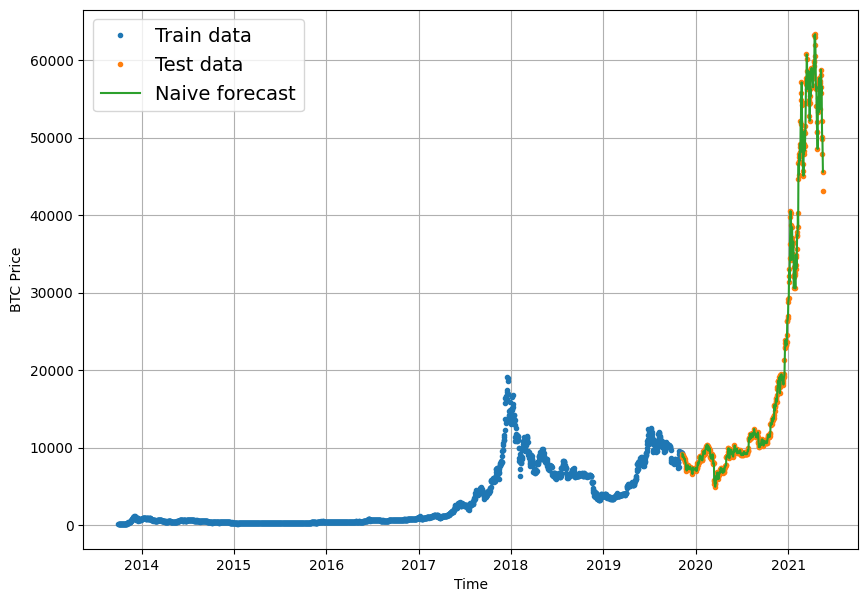

In [13]:
# Plot naive forecast
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Train data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format="-", label="Naive forecast");

In [14]:
import tensorflow as tf

In [15]:
# MASE implemented courtesy of sktime - https://github.com/alan-turing-institute/sktime/blob/ee7a06843a44f4aaec7582d847e36073a9ab0566/sktime/performance_metrics/forecasting/_functions.py#L16
def mean_absolute_scaled_error(y_true, y_pred):
  """
  Implement MASE (assuming no seasonality of data).
  """
  mae = tf.reduce_mean(tf.abs(y_true - y_pred))

  # Find MAE of naive forecast (no seasonality)
  mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1])) # our seasonality is 1 day (hence the shifting of 1 day)

  return mae / mae_naive_no_season


In [16]:
def evaluate_preds(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)

    # Instantiate the metric class
    mae_metric = tf.keras.metrics.MeanAbsoluteError()
    mse_metric = tf.keras.metrics.MeanSquaredError()
    mape_metric = tf.keras.metrics.MeanAbsolutePercentageError()
    rmse_metric = tf.keras.metrics.RootMeanSquaredError()

    # Update the object created with the values
    mae_metric.update_state(y_true, y_pred)
    mse_metric.update_state(y_true, y_pred)
    mape_metric.update_state(y_true, y_pred)
    rmse_metric.update_state(y_true, y_pred)

    # Evaluate the result and convert to numpy
    mae = mae_metric.result().numpy()
    mse = mse_metric.result().numpy()
    mape = mape_metric.result().numpy()
    rmse = rmse_metric.result().numpy()

    # Call our own function
    mase = mean_absolute_scaled_error(y_true, y_pred).numpy()

    # Return the dictionary object
    return {"mae": mae,
            "mse": mse,
            "rmse": rmse,
            "mape": mape,
            "mase": mase}


In [17]:
naive_results = evaluate_preds(y_true=y_test[1:],
                               y_pred=naive_forecast)
naive_results

{'mae': np.float32(567.9802),
 'mse': np.float32(1147547.0),
 'rmse': np.float32(1071.2362),
 'mape': np.float32(2.516525),
 'mase': np.float32(0.99957)}

In [18]:
naive_forecast[-10:]

array([57107.12067189, 58788.20967893, 58102.19142623, 55715.54665129,
       56573.5554719 , 52147.82118698, 49764.1320816 , 50032.69313676,
       47885.62525472, 45604.61575361])

## Format data part 2: windowind the dataset

In [19]:
len(y_train)

2229

In [20]:
print(btc_price[:7], btc_price[7])

[123.65499, 125.455, 108.58483, 118.67466, 121.33866, 120.65533, 121.795] 123.033


In [21]:
# global variables
HORIZON = 1
WINDOW_SIZE = 7

In [22]:
# create a function to label windowed data
def get_labelled_windows(x, horizon=1):
  """
  Creates labels for windowed dataset.

  E.g. if horizon=1 (default)
  Input: [1, 2, 3, 4, 5, 6] -> Output: ([1, 2, 3, 4, 5], [6])
  """
  return x[:, :-horizon], x[:, -horizon:]

In [23]:
# test out the window labelling function
test_window, test_label = get_labelled_windows(tf.expand_dims(tf.range(8)+1, axis=0))
test_window, test_label

(<tf.Tensor: shape=(1, 7), dtype=int32, numpy=array([[1, 2, 3, 4, 5, 6, 7]], dtype=int32)>,
 <tf.Tensor: shape=(1, 1), dtype=int32, numpy=array([[8]], dtype=int32)>)

In [24]:
import numpy as np

# Create function to view NumPy arrays as windows
def make_windows(x, window_size=7, horizon=1):
  """
  Turns a 1D array into a 2D array of sequential windows of window_size.
  """
  # 1. Create a window of specific window_size (add the horizon on the end for later labelling)
  window_step = np.expand_dims(np.arange(window_size+horizon), axis=0)
  # print(f"Window step:\n {window_step}")

  # 2. Create a 2D array of multiple window steps (minus 1 to account for 0 indexing)
  window_indexes = window_step + np.expand_dims(np.arange(len(x)-(window_size+horizon-1)), axis=0).T # create 2D array of windows of size window_size
  # print(f"Window indexes:\n {window_indexes[:3], window_indexes[-3:], window_indexes.shape}")

  # 3. Index on the target array (time series) with 2D array of multiple window steps
  windowed_array = x[window_indexes]

  # 4. Get the labelled windows
  windows, labels = get_labelled_windows(windowed_array, horizon=horizon)

  return windows, labels

In [25]:
# make_windows(prices)
full_windows, full_labels = make_windows(prices)
len(full_windows), len(full_labels)

(2780, 2780)

In [26]:
for i in range(3):
  print(f"Window :{full_windows[i]} -> Label: {full_labels[i]}")

Window :[123.65499 125.455   108.58483 118.67466 121.33866 120.65533 121.795  ] -> Label: [123.033]
Window :[125.455   108.58483 118.67466 121.33866 120.65533 121.795   123.033  ] -> Label: [124.049]
Window :[108.58483 118.67466 121.33866 120.65533 121.795   123.033   124.049  ] -> Label: [125.96116]


In [27]:
def make_train_test_splits(windows, labels, test_split=0.2):
  split_size = int(len(windows) * (1 - test_split))
  train_windows = windows[:split_size]
  train_labels = labels[:split_size]
  test_windows = windows[split_size:]
  test_labels = labels[split_size:]
  return train_windows, test_windows, train_labels, test_labels

In [28]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2224, 556, 2224, 556)

## Make a modelling checkpoint
Because our model's performance will fluctuate from experiment to experiment, we are going to create a model checkpoint to compare results



In [29]:
import os

def create_model_checkpoint(model_name, save_path="model_experiments"):
  return tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(save_path, model_name),
                                            verbose=0,
                                            save_best_only=True)

## Model 1: dense model (window=7, horizon=1)

* single dense layer
* output layer with linear activation
* Adam optimization and MAE loss function
* batch size 128
* 100 epochsno

In [30]:
import tensorflow as tf
from tensorflow.keras import layers

tf.random.set_seed(42)

# create model
model_1 = tf.keras.Sequential([
    layers.Dense(128, activation="relu"),
    layers.Dense(HORIZON, activation="linear")
], name="model_1_dense")

# compile model
model_1.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae", "mse"]
)

# fit model
model_1.fit(
    x=train_windows,
    y=train_labels,
    epochs=100,
    verbose=1,
    batch_size=128,
    validation_data=(test_windows, test_labels),
    callbacks=[create_model_checkpoint(model_name=model_1.name + ".keras")]
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 2145.5662 - mae: 2145.5662 - mse: 14261916.0000 - val_loss: 1116.2025 - val_mae: 1116.2025 - val_mse: 4076248.0000
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 434.1046 - mae: 434.1046 - mse: 702912.0625 - val_loss: 2030.7111 - val_mae: 2030.7111 - val_mse: 9500786.0000
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 240.3206 - mae: 240.3206 - mse: 267804.4688 - val_loss: 1120.1909 - val_mae: 1120.1909 - val_mse: 3757562.0000
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 181.3386 - mae: 181.3386 - mse: 176648.7656 - val_loss: 1051.6880 - val_mae: 1051.6880 - val_mse: 3341455.2500
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 170.8840 - mae: 170.8840 - mse: 155355.0781 - val_loss: 958.2115 - val_mae: 958.2115 - val_mse: 2973819.7500
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 166.6609 - mae: 166.6609 - mse: 147161.0938 - val_loss: 951.9142 - val_mae: 951.9142 

In [31]:
# evaluate model on test data
model_1.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 574.3824 - mae: 574.3824 - mse: 1174945.2500


[574.3824462890625, 574.3824462890625, 1174945.25]

In [32]:
# load based performance model and validate test data
model_1_loaded = tf.keras.models.load_model("model_experiments/model_1_dense.keras")
model_1_loaded.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 567.2044 - mae: 567.2044 - mse: 1166047.2500


[567.2044067382812, 567.2044067382812, 1166047.25]

## making forecast with a model (on test data)

In [33]:
def make_preds(model, input_data):
  forecast = model.predict(input_data)
  return tf.squeeze(forecast)

In [34]:
# mAKE PREDICTIONS USING MODEL_1 on test data

model_1_preds = make_preds(model_1_loaded, test_windows)
model_1_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8837.584, 8783.142, 9024.876, 8775.015, 8721.678, 8702.966,
       8666.505, 8537.789, 8424.818, 8523.012], dtype=float32)>

In [35]:
# evaluate preds
model_1_results = evaluate_preds(y_true=test_labels, y_pred=model_1_preds)
model_1_results

{'mae': np.float32(567.20435),
 'mse': np.float32(1166047.2),
 'rmse': np.float32(1079.8367),
 'mape': np.float32(2.5494566),
 'mase': np.float32(30.086763)}

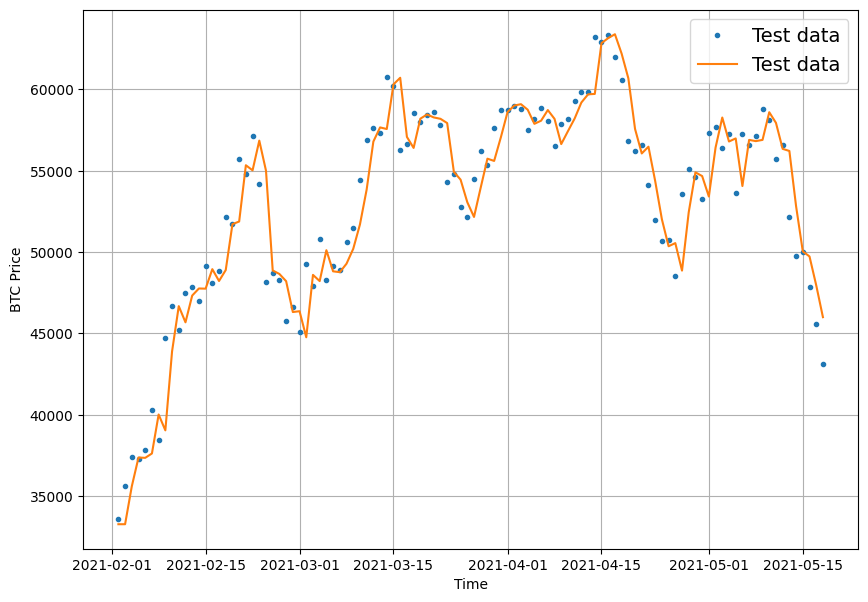

In [36]:
# plot model_1 preds
offset = 450
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels, start=offset, label="Test data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_1_preds, start=offset, format="-", label="Test data")

Model 2: dense model (window=30, horizon=1)

In [37]:
# global variables
HORIZON = 1
WINDOW_SIZE = 30

In [38]:
# make windowed data
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(2757, 2757)

In [39]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2205, 552, 2205, 552)

In [40]:
tf.random.set_seed(42)

# create model
model_2 = tf.keras.Sequential([
    layers.Dense(128, activation="relu"),
    layers.Dense(HORIZON, activation="linear")
], name="model_2_dense")

# compile model
model_2.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae", "mse"]
)

# fit model
model_2.fit(
    x=train_windows,
    y=train_labels,
    epochs=100,
    verbose=1,
    batch_size=128,
    validation_data=(test_windows, test_labels),
    callbacks=[create_model_checkpoint(model_name=model_2.name + ".keras")]
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 1219.2544 - mae: 1219.2544 - mse: 5951243.0000 - val_loss: 4736.2578 - val_mae: 4736.2578 - val_mse: 46390652.0000
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 466.7614 - mae: 466.7614 - mse: 884570.8750 - val_loss: 1743.7238 - val_mae: 1743.7238 - val_mse: 9212610.0000
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 337.0052 - mae: 337.0052 - mse: 523869.8125 - val_loss: 1578.5675 - val_mae: 1578.5675 - val_mse: 7659666.5000
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 278.9985 - mae: 278.9985 - mse: 373643.4062 - val_loss: 1435.5786 - val_mae: 1435.5786 - val_mse: 6422639.5000
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 256.9252 - mae: 256.9252 - mse: 311582.8438 - val_loss: 1313.8945 - val_mae: 1313.8945 - val_mse: 5357722.5000
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 236.2731 - mae: 236.2731 - mse: 261000.3281 - val_loss: 1305.0565 - val_mae: 1305.0565

In [41]:
# evaluate model on test data
model_2.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 766.8304 - mae: 766.8304 - mse: 1722807.2500


[766.8304443359375, 766.8304443359375, 1722807.25]

In [42]:
# load based performance model and validate test data
model_2_loaded = tf.keras.models.load_model("model_experiments/model_2_dense.keras")
model_2_loaded.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 597.3340 - mae: 597.3340 - mse: 1228138.3750


[597.3340454101562, 597.3340454101562, 1228138.375]

In [43]:
# mAKE PREDICTIONS USING MODEL_2 on test data

model_2_preds = make_preds(model_2_loaded, test_windows)
model_2_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8768.631 , 8869.697 , 8867.275 , 8566.069 , 8356.044 , 8342.474 ,
       8158.988 , 8126.16  , 8043.84  , 7769.4565], dtype=float32)>

In [44]:
# evaluate preds
model_2_results = evaluate_preds(y_true=test_labels, y_pred=model_2_preds)
model_2_results

{'mae': np.float32(597.334),
 'mse': np.float32(1228138.4),
 'rmse': np.float32(1108.214),
 'mape': np.float32(2.7062173),
 'mase': np.float32(30.072697)}

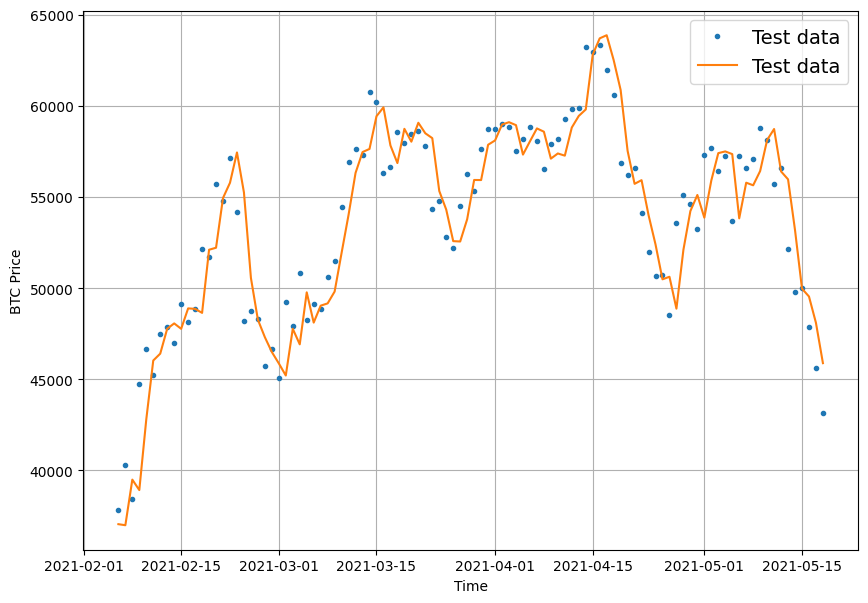

In [45]:
# plot model_2 preds
offset = 450
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels, start=offset, label="Test data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_2_preds, start=offset, format="-", label="Test data")

## model 3: dense (window=30, horizon=7)

In [46]:
import os

def create_model_checkpoint(model_name, save_path="model_experiments"):
  return tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(save_path, model_name),
                                            verbose=0,
                                            save_best_only=True)

In [47]:
# global variables
HORIZON = 7
WINDOW_SIZE = 30

In [48]:
HORIZON = 7
WINDOW_SIZE = 30

full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(2751, 2751)

In [49]:
full_windows.shape, full_labels.shape

((2751, 30), (2751, 7))

In [50]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows=full_windows, labels=full_labels, test_split=0.2)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2200, 551, 2200, 551)

In [51]:
train_labels[:10]

array([[196.02499, 198.04883, 198.93233, 200.543  , 210.3075 , 225.02   ,
        248.25333],
       [198.04883, 198.93233, 200.543  , 210.3075 , 225.02   , 248.25333,
        262.32666],
       [198.93233, 200.543  , 210.3075 , 225.02   , 248.25333, 262.32666,
        294.48699],
       [200.543  , 210.3075 , 225.02   , 248.25333, 262.32666, 294.48699,
        331.10325],
       [210.3075 , 225.02   , 248.25333, 262.32666, 294.48699, 331.10325,
        285.8875 ],
       [225.02   , 248.25333, 262.32666, 294.48699, 331.10325, 285.8875 ,
        304.97974],
       [248.25333, 262.32666, 294.48699, 331.10325, 285.8875 , 304.97974,
        338.137  ],
       [262.32666, 294.48699, 331.10325, 285.8875 , 304.97974, 338.137  ,
        357.48   ],
       [294.48699, 331.10325, 285.8875 , 304.97974, 338.137  , 357.48   ,
        402.954  ],
       [331.10325, 285.8875 , 304.97974, 338.137  , 357.48   , 402.954  ,
        409.10375]])

In [52]:
train_windows[:10]

array([[123.65499, 125.455  , 108.58483, 118.67466, 121.33866, 120.65533,
        121.795  , 123.033  , 124.049  , 125.96116, 125.27966, 125.9275 ,
        126.38333, 135.24199, 133.20333, 142.76333, 137.92333, 142.95166,
        152.55183, 160.33883, 164.31499, 177.63333, 188.29716, 200.70166,
        180.355  , 175.03166, 177.6965 , 187.15983, 192.75666, 197.4    ],
       [125.455  , 108.58483, 118.67466, 121.33866, 120.65533, 121.795  ,
        123.033  , 124.049  , 125.96116, 125.27966, 125.9275 , 126.38333,
        135.24199, 133.20333, 142.76333, 137.92333, 142.95166, 152.55183,
        160.33883, 164.31499, 177.63333, 188.29716, 200.70166, 180.355  ,
        175.03166, 177.6965 , 187.15983, 192.75666, 197.4    , 196.02499],
       [108.58483, 118.67466, 121.33866, 120.65533, 121.795  , 123.033  ,
        124.049  , 125.96116, 125.27966, 125.9275 , 126.38333, 135.24199,
        133.20333, 142.76333, 137.92333, 142.95166, 152.55183, 160.33883,
        164.31499, 177.63333, 188.29

In [53]:
train_windows.shape, train_labels.shape

((2200, 30), (2200, 7))

In [54]:
tf.random.set_seed(42)

# Create model (same as model_1 except with different data input size)
model_3 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON)
], name="model_3_dense")

model_3.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

model_3.fit(train_windows,
            train_labels,
            batch_size=128,
            epochs=100,
            verbose=0,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_3.name + ".keras")])

In [55]:
# evaluate model on test data
model_3.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1280.0916


1280.091552734375

In [56]:
# load based performance model and validate test data
model_3_loaded = tf.keras.models.load_model("model_experiments/model_3_dense.keras")
model_3_loaded.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1272.0281


1272.028076171875

In [57]:
# mAKE PREDICTIONS USING MODEL_3 on test data

model_3_preds = make_preds(model_3_loaded, test_windows)
model_3_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


<tf.Tensor: shape=(10, 7), dtype=float32, numpy=
array([[9714.049 , 9718.185 , 9620.726 , 9605.255 , 9769.158 , 9806.56  ,
        9305.285 ],
       [9479.412 , 9478.825 , 9401.004 , 9392.541 , 9538.266 , 9363.608 ,
        8956.348 ],
       [9240.42  , 9214.138 , 9306.251 , 9153.441 , 9173.027 , 9137.8545,
        9016.75  ],
       [9191.309 , 9248.911 , 9397.345 , 9341.091 , 9243.154 , 9473.698 ,
        9199.892 ],
       [8971.695 , 9084.157 , 9312.895 , 9188.409 , 9300.869 , 9145.507 ,
        8940.365 ],
       [8924.093 , 8981.923 , 9327.928 , 9176.719 , 9250.715 , 9055.401 ,
        8718.689 ],
       [9072.209 , 9160.435 , 9275.22  , 9193.47  , 9068.273 , 8918.804 ,
        8560.83  ],
       [9072.295 , 9265.909 , 8956.731 , 8869.441 , 8815.591 , 8862.489 ,
        8584.558 ],
       [8902.658 , 8938.14  , 8731.666 , 8585.183 , 8594.984 , 8761.97  ,
        8333.46  ],
       [8694.561 , 8682.769 , 8681.22  , 8563.943 , 8592.004 , 8667.109 ,
        8370.155 ]], dtype=floa

In [58]:
# evaluate preds
model_3_results = evaluate_preds(y_true=test_labels, y_pred=model_3_preds)
model_3_results

{'mae': np.float32(1272.0281),
 'mse': np.float32(5539049.0),
 'rmse': np.float32(2353.5183),
 'mape': np.float32(5.8955274),
 'mase': np.float32(2.2635028)}

In [59]:
model_3_preds.shape

TensorShape([551, 7])

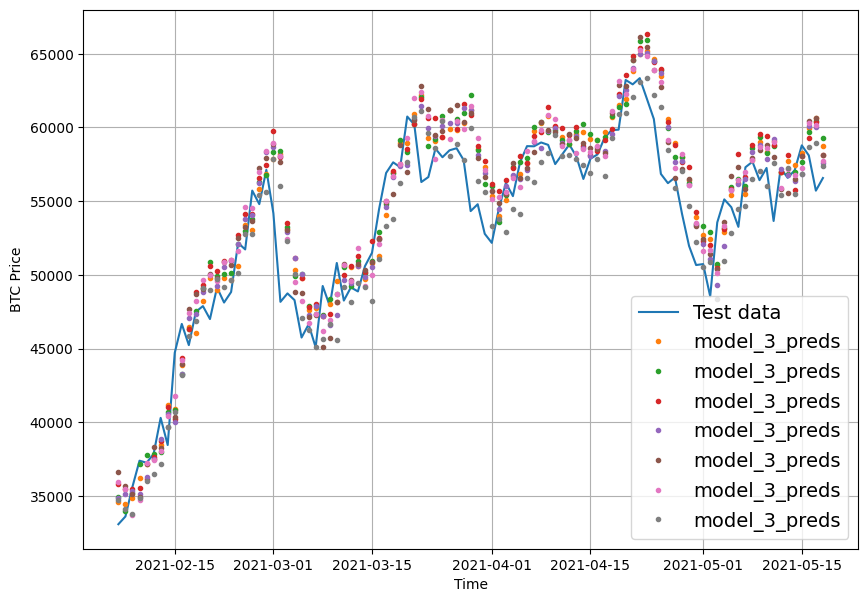

In [60]:
# plot model_3 preds
offset = 450
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, format="-", label="Test data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_3_preds, start=offset, label="model_3_preds")

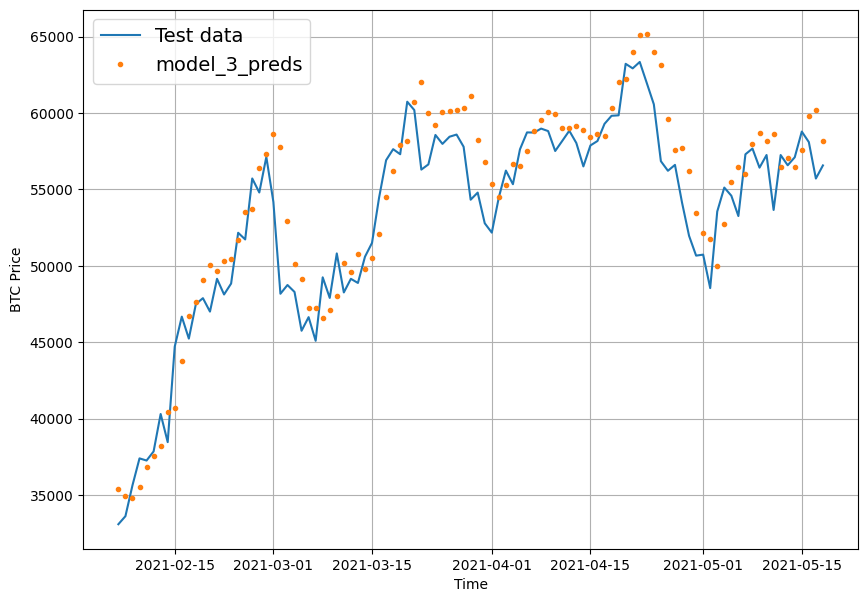

In [61]:
# plot model_3 preds
offset = 450
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, format="-", label="Test data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=tf.reduce_mean(model_3_preds, axis=1), start=offset, label="model_3_preds")

<Axes: >

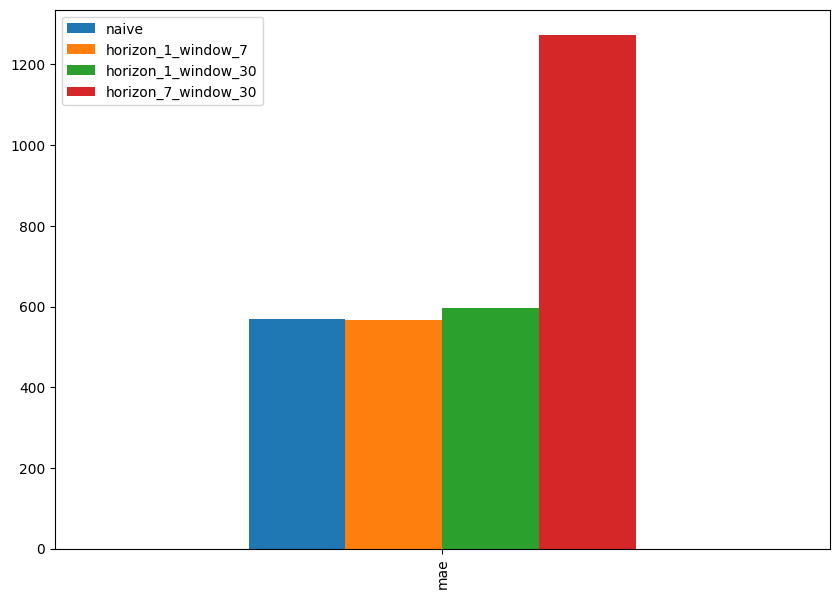

In [62]:
pd.DataFrame({
    "naive": naive_results["mae"],
    "horizon_1_window_7": model_1_results["mae"],
    "horizon_1_window_30": model_2_results["mae"],
    "horizon_7_window_30": model_3_results["mae"]
}, index=["mae"]).plot(figsize=(10,7), kind="bar")

## model 4: conv1D

In [63]:
# global variables
HORIZON = 1
WINDOW_SIZE = 7

In [64]:
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

(2780, 2780)

In [65]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows=full_windows, labels=full_labels, test_split=0.2)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2224, 556, 2224, 556)

In [66]:
x = tf.constant(train_windows[0])
x

<tf.Tensor: shape=(7,), dtype=float64, numpy=
array([123.65499, 125.455  , 108.58483, 118.67466, 121.33866, 120.65533,
       121.795  ])>

In [67]:
expand_dims_layer = layers.Lambda(lambda x: tf.expand_dims(x, axis=1))

In [68]:
print(x.shape)
print(expand_dims_layer(x).shape)
print(expand_dims_layer(x))

(7,)
(7, 1)
tf.Tensor(
[[123.65499]
 [125.455  ]
 [108.58483]
 [118.67466]
 [121.33866]
 [120.65533]
 [121.795  ]], shape=(7, 1), dtype=float32)


In [69]:
tf.random.set_seed(42)

def exp_dim(x):
  return tf.expand_dims(x, axis=1)

# Create model
model_4 = tf.keras.Sequential([
  # Create Lambda layer to reshape inputs, without this layer, the model will error
  layers.Lambda(exp_dim), # resize the inputs to adjust for window size / Conv1D 3D input requirements
  layers.Conv1D(filters=128, kernel_size=5, padding="causal", activation="relu"),
  layers.Dense(HORIZON)
], name="model_4_conv1d")

# Compile model
model_4.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

# Fit model
model_4.fit(train_windows,
            train_labels,
            batch_size=128,
            epochs=100,
            verbose=0,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_4.name + ".keras")])

In [70]:
# evaluate model on test data
model_4.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 573.2468


573.246826171875

In [71]:
model_4_loaded = tf.keras.models.load_model("model_experiments/model_4_conv1d.keras", custom_objects={"exp_dim": exp_dim})
model_4_loaded.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 566.4969


566.4968872070312

In [72]:
# mAKE PREDICTIONS USING MODEL_3 on test data

model_4_preds = make_preds(model_4_loaded, test_windows)
model_4_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8874.466, 8785.439, 8998.75 , 8779.234, 8752.623, 8733.684,
       8674.991, 8533.284, 8460.904, 8515.75 ], dtype=float32)>

In [73]:
# evaluate preds
model_4_results = evaluate_preds(y_true=test_labels, y_pred=model_4_preds)
model_4_results

{'mae': np.float32(566.4968),
 'mse': np.float32(1167839.2),
 'rmse': np.float32(1080.6661),
 'mape': np.float32(2.5320039),
 'mase': np.float32(30.113983)}

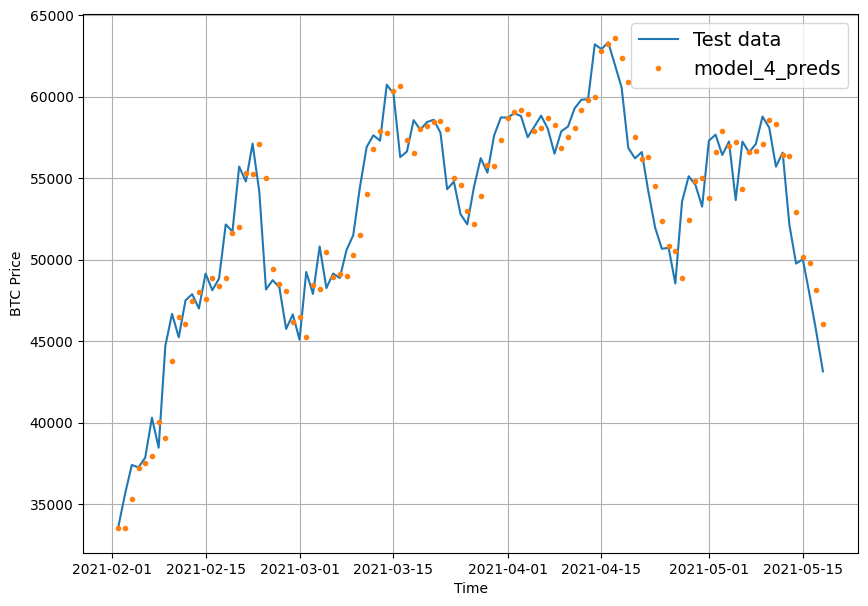

In [74]:
# plot model_4 preds
offset = 450
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, format="-", label="Test data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_4_preds, start=offset, label="model_4_preds")

## Model 5: RNN (LSTM)

In [75]:
tf.random.set_seed(42)

def exp_dim(x):
  return tf.expand_dims(x, axis=1)

inputs = layers.Input(shape=(WINDOW_SIZE,))
x = layers.Lambda(exp_dim)(inputs)
# x = layers.LSTM(128, return_sequences=True)(x)
x = layers.LSTM(128, activation="relu")(x)
# x = layers.Dense(32, activation="relu")(x)
output = layers.Dense(HORIZON)(x)

# Create model
model_5 = tf.keras.Model(inputs=inputs, outputs=output, name="model_5_lstm")

# Compile model
model_5.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam())

# Fit model
model_5.fit(train_windows,
            train_labels,
            batch_size=128,
            epochs=100,
            verbose=1,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_5.name + ".keras")])

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 2891.8240 - val_loss: 14061.5957
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1577.6602 - val_loss: 4924.6426
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 350.6916 - val_loss: 1270.0511
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 201.6277 - val_loss: 1058.6244
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 185.1109 - val_loss: 1099.8308
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 181.8609 - val_loss: 1047.0084
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 179.9014 - val_loss: 1038.2328
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 178.7413 - val_loss: 1034.6442
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 177.5963 - val_loss: 1031.1901
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 176.4362 - val_loss: 1025.3591
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 175.1331 - val_loss: 1023.9

In [76]:
model_5_loaded = tf.keras.models.load_model("model_experiments/model_5_lstm.keras", custom_objects={"exp_dim": exp_dim})
model_5_loaded.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 582.7867


582.7866821289062

In [77]:
# mAKE PREDICTIONS USING MODEL_5 on test data

model_5_preds = make_preds(model_5_loaded, test_windows)
model_5_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8897.513, 8791.213, 8972.01 , 8760.817, 8711.955, 8705.53 ,
       8684.462, 8515.51 , 8443.255, 8501.877], dtype=float32)>

In [78]:
# evaluate preds
model_5_results = evaluate_preds(y_true=test_labels, y_pred=model_5_preds)
model_5_results

{'mae': np.float32(582.7867),
 'mse': np.float32(1210153.6),
 'rmse': np.float32(1100.0698),
 'mape': np.float32(2.6318965),
 'mase': np.float32(30.080544)}

## Make a multivariate time series

In [79]:
block_reward_1 = 50
block_reward_2 = 25
block_reward_3 = 12.5
block_reward_4 = 6.25

block_reward_2_datetime = np.datetime64("2012-11-28")
block_reward_3_datetime = np.datetime64("2016-07-09")
block_reward_4_datetime = np.datetime64("2020-05-18")

In [80]:
block_reward_2_days = (block_reward_3_datetime - bitcoin_prices.index[0]).days
block_reward_3_days = (block_reward_4_datetime - bitcoin_prices.index[0]).days

In [81]:
bitcoin_prices_block = bitcoin_prices.copy()
bitcoin_prices_block["block_reward"] = None

bitcoin_prices_block.iloc[: block_reward_2_days, -1] = block_reward_2
bitcoin_prices_block.iloc[block_reward_2_days : block_reward_3_days, -1] = block_reward_3
bitcoin_prices_block.iloc[block_reward_3_days : , -1] = block_reward_4

## windowed datasets with pandas

In [82]:
# global variables
HORIZON = 1
WINDOW_SIZE = 7

In [83]:
bitcoin_prices_windowed = bitcoin_prices_block.copy()

for i in range(WINDOW_SIZE):
  bitcoin_prices_windowed[f"Price+{i+1}"] = bitcoin_prices_windowed["Price"].shift(periods=i+1)

bitcoin_prices_windowed.head(10)

,Price,block_reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,,
2013-10-01,123.65499,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-02,125.45500,25,123.65499,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-03,108.58483,25,125.45500,123.65499,NaN,NaN,NaN,NaN,NaN
2013-10-04,118.67466,25,108.58483,125.45500,123.65499,NaN,NaN,NaN,NaN
2013-10-05,121.33866,25,118.67466,108.58483,125.45500,123.65499,NaN,NaN,NaN
2013-10-06,120.65533,25,121.33866,118.67466,108.58483,125.45500,123.65499,NaN,NaN
2013-10-07,121.79500,25,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499,NaN
2013-10-08,123.03300,25,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499
2013-10-09,124.04900,25,123.03300,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500


In [84]:
X = bitcoin_prices_windowed.dropna().drop("Price", axis=1).astype(np.float32)
y = bitcoin_prices_windowed.dropna()["Price"].astype(np.float32)
X.head()

,block_reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,
2013-10-08,25.0,121.794998,120.655327,121.338661,118.674660,108.584831,125.455002,123.654991
2013-10-09,25.0,123.032997,121.794998,120.655327,121.338661,118.674660,108.584831,125.455002
2013-10-10,25.0,124.049004,123.032997,121.794998,120.655327,121.338661,118.674660,108.584831
2013-10-11,25.0,125.961159,124.049004,123.032997,121.794998,120.655327,121.338661,118.674660
2013-10-12,25.0,125.279663,125.961159,124.049004,123.032997,121.794998,120.655327,121.338661


In [85]:
# make train and test datasets
split_size = int(len(X) *0.8)
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]
len(X_train), len(y_train), len(X_test), len(y_test)

(2224, 2224, 556, 556)

# Model 6: dense (multivariate)

In [86]:
tf.random.set_seed(42)

# create model
model_6 = tf.keras.Sequential([
    layers.Dense(128, activation="relu"),
    layers.Dense(HORIZON)
], name="model_6_dense_multivriate")

# compile model
model_6.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.Adam(),
    # metrics=["mae", "mse"]
)

# fit model
model_6.fit(
    x=X_train,
    y=y_train,
    epochs=100,
    verbose=1,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[create_model_checkpoint(model_name=model_6.name + ".keras")])

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 3152.2600 - val_loss: 6038.7383
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 505.1320 - val_loss: 1147.1410
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 239.6416 - val_loss: 1184.1329
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 198.8045 - val_loss: 1046.6699
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 187.7644 - val_loss: 1048.9363
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 181.2539 - val_loss: 1045.3170
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 177.8549 - val_loss: 1033.5631
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 174.4017 - val_loss: 999.2664
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 170.4479 - val_loss: 964.1179
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 166.5017 - val_loss: 946.9961
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 162.6485 - val_loss: 917.9365
Epoch 

In [87]:
# evaluate model on test data
model_6.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 570.6305


570.6304931640625

In [88]:
model_6_loaded = tf.keras.models.load_model("model_experiments/model_6_dense_multivriate.keras")
model_6_loaded.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 570.6305


570.6304931640625

In [89]:
# mAKE PREDICTIONS USING MODEL_5 on test data

model_6_preds = make_preds(model_6_loaded, X_test)
model_6_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8892.116, 8790.604, 9056.659, 8841.167, 8734.277, 8754.577,
       8724.343, 8536.786, 8477.833, 8550.353], dtype=float32)>

In [90]:
# evaluate preds
model_6_results = evaluate_preds(y_true=y_test, y_pred=model_6_preds)
model_6_results

{'mae': np.float32(570.6305),
 'mse': np.float32(1181126.0),
 'rmse': np.float32(1086.7961),
 'mape': np.float32(2.5544586),
 'mase': np.float32(1.0024397)}

## Model 7: N-Beats algorithm

In [91]:
# create NBeatBlock custom layer
class NBeatBlock(tf.keras.layers.Layer):
  # __slots__=(va1,var2)
  def __init__(self,
               input_size: int,
               theta_size: int,
               horizon: int,
               n_neurons: int,
               n_layers: int,**kwargs): # takes care of all arguments from the parent class
    super().__init__(**kwargs)
    self.input_size = input_size
    self.theta_size = theta_size
    self.horizon = horizon
    self.n_neurons = n_neurons
    self.n_layers = n_layers

    # creates an stack of n_layers fully connected layers
    self.hidden = [tf.keras.layers.Dense(n_neurons, activation="relu") for _ in range(n_layers)]
    # output block is a theta layer with linear activation
    self.theta_layer = tf.keras.layers.Dense(theta_size, activation="linear", name="theta")

  def call(self, inputs):
    x = inputs
    for layer in self.hidden:
      x = layer(x)
    theta = self.theta_layer(x)
    backcast, forecast = theta[:, :self.input_size], theta[:, -self.horizon:]
    return backcast, forecast


In [92]:
# dummy nbeat layer
dummy_nbeats_block_layer =NBeatBlock(
    input_size=WINDOW_SIZE,
    theta_size=WINDOW_SIZE+HORIZON,
    horizon=HORIZON,
    n_neurons=128,
    n_layers=4
)

In [93]:
# dummy inputs
dummy_inputs = tf.expand_dims(tf.range(WINDOW_SIZE) + 1, axis=0)
dummy_inputs

<tf.Tensor: shape=(1, 7), dtype=int32, numpy=array([[1, 2, 3, 4, 5, 6, 7]], dtype=int32)>

In [94]:
backcast, forecast = dummy_nbeats_block_layer(dummy_inputs)
print(f"Backcast: {tf.squeeze(backcast.numpy())}")
print(f"Forecast: {tf.squeeze(forecast.numpy())}")

Backcast: [-0.33889884  0.07467626  0.17189644  0.24685402  0.03723842 -0.2784401
 -0.29768783]
Forecast: 0.08875790238380432


### Preparing data for the N-BEATS algorithm using `tf.data`

In [95]:
# global variables
HORIZON = 1
WINDOW_SIZE = 7

In [96]:
# Create N-BEATS data inputs (one variable time series)
# add windowed columns
bitcoin_prices_nbeats = bitcoin_prices.copy()
for i in range(WINDOW_SIZE):
  bitcoin_prices_nbeats[f"Price+{i+1}"] = bitcoin_prices_nbeats["Price"].shift(periods=i+1)

bitcoin_prices_nbeats.head()

,Price,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,
2013-10-01,123.65499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-02,125.45500,123.65499,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-03,108.58483,125.45500,123.65499,NaN,NaN,NaN,NaN,NaN
2013-10-04,118.67466,108.58483,125.45500,123.65499,NaN,NaN,NaN,NaN
2013-10-05,121.33866,118.67466,108.58483,125.45500,123.65499,NaN,NaN,NaN


In [97]:
# Make features and labels
X = bitcoin_prices_nbeats.dropna().drop("Price", axis=1)
y = bitcoin_prices_nbeats.dropna()["Price"]

# make train and test datasets
split_size = int(len(X) * 0.8)
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]
len(X_train), len(y_train), len(X_test), len(y_test)

(2224, 2224, 556, 556)

In [98]:
# tf.data API
train_features_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_labels_dataset = tf.data.Dataset.from_tensor_slices(y_train)
test_features_dataset = tf.data.Dataset.from_tensor_slices(X_test)
test_labels_dataset = tf.data.Dataset.from_tensor_slices(y_test)

# combine labels and features
train_dataset = tf.data.Dataset.zip((train_features_dataset, train_labels_dataset))
test_dataset = tf.data.Dataset.zip((test_features_dataset, test_labels_dataset))

# batch and prefetch
BATCH_SIZE = 1024
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset, test_dataset

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>)

### Setting hyperparameters for N-BEATS algorithm

In [99]:
N_EPOCHS = 5000
N_NEURONS = 512
N_LAYERS = 4
N_STACKS = 30

INPUT_SIZE = WINDOW_SIZE * HORIZON
THETA_SIZE = INPUT_SIZE + HORIZON

INPUT_SIZE, THETA_SIZE

(7, 8)

## Residual connections

In [100]:
# Make tensors
tensor_1 = tf.range(10) + 10
tensor_2 = tf.range(10)

# subtracted
subtracted = layers.subtract([tensor_1, tensor_2])

# add
added = layers.add([tensor_1, tensor_2])

subtracted.numpy(), added.numpy()

(array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10], dtype=int32),
 array([10, 12, 14, 16, 18, 20, 22, 24, 26, 28], dtype=int32))

In [101]:
%%time

tf.random.set_seed(42)

# 1. setup instance of N_BEATS block
nbeats_block_layer = NBeatBlock(
    input_size=INPUT_SIZE,
    theta_size=THETA_SIZE,
    horizon=HORIZON,
    n_neurons=N_NEURONS,
    n_layers=N_LAYERS,
    name="InitialBlock"
)

# 2. create input to stack
# FIXED: shape must be a tuple, so we use (INPUT_SIZE,)
stack_input = layers.Input(shape=(INPUT_SIZE,), name="stack_input")

# 3. create initial backcast and forecast input
residuals, forecast = nbeats_block_layer(stack_input)

# 4. create stacks of block layers
for i, _ in enumerate(range(N_STACKS-1)):
  # 5. Use NBeatsBlock to calculate backcast and forecast
  backcast, block_forecast = NBeatBlock(
      input_size=INPUT_SIZE,
      theta_size=THETA_SIZE,
      horizon=HORIZON,
      n_neurons=N_NEURONS,
      n_layers=N_LAYERS,
      name=f"NBeatBlock_{i}"
  )(residuals)
  # 6. create the double residual stacking
  residuals = layers.subtract([residuals, backcast], name=f"subtract_{i}")
  forecats = layers.add([forecast, block_forecast], name=f"add_{i}")

# 7. assemble stack model
model_7 = tf.keras.Model(inputs=stack_input, outputs=forecast, name="model_7_nbeats")

# 8. compile
model_7.compile(
    loss = "mae",
    optimizer=tf.keras.optimizers.Adam()
)

# 9. fit the model with early stopping callback
model_7.fit(
    train_dataset,
    epochs=N_EPOCHS,
    validation_data=test_dataset,
    verbose=0,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=200, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=100, verbose=1)
    ]
)


Epoch 583: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 866: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.

Epoch 966: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
CPU times: user 34.7 s, sys: 2.4 s, total: 37.1 s
Wall time: 40.5 s


In [102]:
# Evaluate Neats model
model_7.evaluate(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 572.5612


572.5611572265625

In [103]:
# Make predictions
model_7_preds = make_preds(model_7, test_dataset)
model_7_preds[:10]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8823.709, 8747.773, 9024.096, 8758.133, 8741.064, 8746.807,
       8658.273, 8487.07 , 8468.276, 8508.51 ], dtype=float32)>

In [104]:
# Evaluate NBeats preds
# Extract the correct labels from the windowed test_dataset to match predictions (556 samples)
y_true_nbeats = [label.numpy() for _, label in test_dataset.unbatch()]

model_7_results = evaluate_preds(y_true=y_true_nbeats, y_pred=model_7_preds)
model_7_results

{'mae': np.float32(572.56116),
 'mse': np.float32(1160672.5),
 'rmse': np.float32(1077.3451),
 'mape': np.float32(2.610522),
 'mase': np.float32(1.0058314)}

### plotting the nbeats architecture

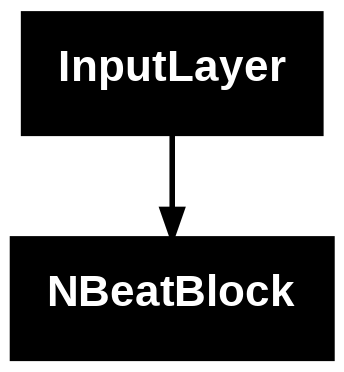

In [105]:
from tensorflow.keras.utils import plot_model
plot_model(model_7)

## model 8: creating an esemble

In [106]:
def get_ensemble_model(horizon=HORIZON,
                       train_data=train_dataset,
                       test_data=test_dataset,
                       num_iter=10,
                       num_epochs=1000,
                       loss_fn=["mae", "mse", "mape"]):
  ensemble_models=[]
  for i in range(num_iter):
    for loss_function in loss_fn:
      print(f"optimizing for {loss_function}, epochs={num_epochs}, model={i}")
      model = tf.keras.Sequential([
          layers.Dense(128, kernel_initializer="he_normal", activation="relu"),
          layers.Dense(128, kernel_initializer="he_normal", activation="relu"),
          layers.Dense(horizon)
      ])
      # compile
      model.compile(loss=loss_function,
                    optimizer=tf.optimizers.Adam(),
                    metrics=["mae", "mse", "mape"])
      # fit
      model.fit(train_data,
                epochs=num_epochs,
                verbose=0,
                validation_data=test_data,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=200, restore_best_weights=True),
                           tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=100, verbose=1)])
      ensemble_models.append(model)
  return ensemble_models


In [107]:
%%time
# get list of trained ensemble models
ensemble_models = get_ensemble_model(num_iter=5, num_epochs=1000)

optimizing for mae, epochs=1000, model=0

Epoch 620: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 720: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
optimizing for mse, epochs=1000, model=0

Epoch 400: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 500: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
optimizing for mape, epochs=1000, model=0

Epoch 206: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 309: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.

Epoch 409: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
optimizing for mae, epochs=1000, model=1

Epoch 533: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 633: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
optimizing for mse, epochs=1000, model=1

Epoch 348: ReduceLROnPlateau reducing learning rate to 0.0001000000047497

In [108]:
# make predictions
def make_ensemble_preds(models, data):
  preds = []
  for model in models:
    preds.append(model.predict(data))
  return tf.constant(tf.squeeze(preds))

In [109]:
%%time
ensemble_preds=make_ensemble_preds(models=ensemble_models, data=test_dataset)
ensemble_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
CPU times: user 2.62 s, sys: 107 ms, total: 2.72 s
Wall time: 3.05 s


<tf.Tensor: shape=(15, 556), dtype=float32, numpy=
array([[ 8805.803,  8734.736,  9000.875, ..., 49330.793, 48047.63 ,
        46487.55 ],
       [ 8785.455,  8733.974,  9036.674, ..., 49664.055, 48896.023,
        46150.58 ],
       [ 8789.171,  8784.465,  9074.62 , ..., 50033.758, 48621.06 ,
        46008.36 ],
       ...,
       [ 8795.908,  8774.576,  9106.175, ..., 49935.504, 48625.36 ,
        45687.57 ],
       [ 8742.939,  8810.257,  9094.174, ..., 49823.027, 48393.113,
        46064.695],
       [ 8814.066,  8838.104,  9017.01 , ..., 49983.957, 47349.242,
        46415.348]], dtype=float32)>

In [110]:
# evaluate
ensemble_results = evaluate_preds(y_true=y_true_nbeats, y_pred=ensemble_preds)
ensemble_results

{'mae': np.float32(574.0956),
 'mse': np.float32(1162413.2),
 'rmse': np.float32(1078.1527),
 'mape': np.float32(2.6175683),
 'mase': np.float32(1.0085269)}

In [111]:
ensemble_mean = tf.reduce_mean(ensemble_preds, axis=0)
ensemble_mean

<tf.Tensor: shape=(556,), dtype=float32, numpy=
array([ 8788.449 ,  8767.934 ,  9058.272 ,  8731.624 ,  8744.237 ,
        8720.377 ,  8658.713 ,  8487.335 ,  8452.53  ,  8523.268 ,
        8207.816 ,  8104.54  ,  8054.85  ,  7634.166 ,  7287.8896,
        7295.656 ,  7076.3257,  7208.2173,  7120.466 ,  7529.8857,
        7396.5303,  7738.9624,  7564.7954,  7386.798 ,  7331.5444,
        7300.1636,  7210.9795,  7387.353 ,  7514.8223,  7542.616 ,
        7551.327 ,  7329.072 ,  7229.895 ,  7177.113 ,  7186.6685,
        7234.6436,  7081.984 ,  7095.5864,  6870.94  ,  6587.005 ,
        7405.813 ,  7171.4297,  7152.885 ,  7265.533 ,  7249.9585,
        7199.7563,  7217.048 ,  7207.4937,  7178.894 ,  7214.415 ,
        7309.1646,  7392.112 ,  7248.963 ,  7167.7676,  7157.0576,
        6948.671 ,  7279.6294,  7341.737 ,  7361.31  ,  7726.577 ,
        8087.4287,  8141.9526,  7850.6123,  8094.444 ,  8108.969 ,
        8168.4   ,  8107.54  ,  8759.525 ,  8912.759 ,  8759.248 ,
        8952.2

In [112]:
ensemble_median = np.median(ensemble_preds, axis=0)
ensemble_median

array([ 8797.242 ,  8774.576 ,  9056.692 ,  8729.677 ,  8744.716 ,
        8716.692 ,  8656.311 ,  8501.124 ,  8454.969 ,  8525.331 ,
        8212.184 ,  8104.919 ,  8061.3877,  7631.269 ,  7284.7847,
        7304.219 ,  7098.1084,  7211.82  ,  7125.692 ,  7531.1885,
        7398.7817,  7740.9756,  7558.645 ,  7391.371 ,  7321.8037,
        7289.304 ,  7215.1113,  7390.0703,  7522.169 ,  7543.691 ,
        7555.9766,  7333.296 ,  7236.66  ,  7181.6553,  7182.237 ,
        7236.983 ,  7085.7124,  7097.005 ,  6875.735 ,  6584.244 ,
        7406.52  ,  7169.146 ,  7159.0044,  7272.6724,  7252.2056,
        7199.971 ,  7221.994 ,  7200.312 ,  7180.9424,  7213.7065,
        7312.0645,  7393.7505,  7244.249 ,  7166.021 ,  7160.9375,
        6954.942 ,  7282.8843,  7343.446 ,  7364.446 ,  7723.975 ,
        8095.453 ,  8136.3667,  7857.102 ,  8095.498 ,  8111.455 ,
        8163.753 ,  8115.0244,  8755.532 ,  8917.882 ,  8762.756 ,
        8951.041 ,  8962.962 ,  8675.81  ,  8635.929 ,  8679.9

In [113]:
# evaluate
ensemble_results = evaluate_preds(y_true=y_true_nbeats, y_pred=ensemble_mean)
ensemble_results

{'mae': np.float32(564.65186),
 'mse': np.float32(1135092.4),
 'rmse': np.float32(1065.4071),
 'mape': np.float32(2.5645423),
 'mase': np.float32(0.9919369)}

In [114]:
# evaluate
ensemble_results = evaluate_preds(y_true=y_true_nbeats, y_pred=ensemble_median)
ensemble_results

{'mae': np.float32(561.19684),
 'mse': np.float32(1125308.4),
 'rmse': np.float32(1060.8055),
 'mape': np.float32(2.549593),
 'mase': np.float32(0.9858674)}

### plotting prediction intervals

In [115]:
# find upper and lower bounds of ensemble predictions
def get_upper_lower(preds):
  std = tf.math.reduce_std(preds, axis=0)
  interval = 1.96 * std
  preds_mean = tf.reduce_mean(preds, axis=0)
  lower, upper = preds_mean - interval, preds_mean + interval
  return lower, upper

In [116]:
lower, upper = get_upper_lower(ensemble_preds)
lower, upper

(<tf.Tensor: shape=(556,), dtype=float32, numpy=
 array([ 8732.856 ,  8695.552 ,  8971.978 ,  8675.412 ,  8665.497 ,
         8665.062 ,  8596.274 ,  8418.404 ,  8371.82  ,  8466.721 ,
         8166.167 ,  8041.6206,  8004.148 ,  7582.953 ,  7215.6245,
         7235.1323,  6985.848 ,  7146.411 ,  7072.133 ,  7433.1377,
         7347.8154,  7657.4775,  7491.164 ,  7313.9243,  7256.2056,
         7236.0396,  7167.969 ,  7325.189 ,  7467.0586,  7503.406 ,
         7524.112 ,  7292.4507,  7186.5415,  7123.926 ,  7147.4966,
         7196.0166,  7033.1655,  7043.591 ,  6831.7324,  6547.1816,
         7301.421 ,  7082.2334,  7037.619 ,  7174.369 ,  7146.661 ,
         7099.1123,  7162.515 ,  7169.932 ,  7149.6445,  7179.0005,
         7270.2827,  7368.603 ,  7217.3247,  7130.363 ,  7119.205 ,
         6915.5615,  7223.4897,  7294.5596,  7306.485 ,  7681.02  ,
         8017.7314,  8080.2134,  7781.7505,  8033.387 ,  8035.4253,
         8129.104 ,  8066.0854,  8673.569 ,  8837.193 ,  8682.953 ,

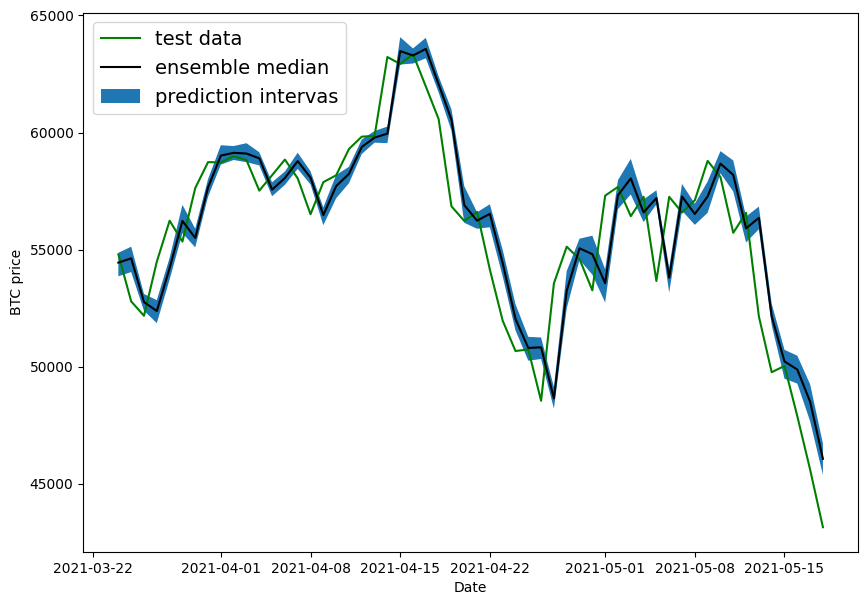

In [117]:
# Get median/mean values of ensemble preds
ensemble_median = np.median(ensemble_preds, axis=0)

# plot median
offset=500
plt.figure(figsize=(10,7))
plt.plot(X_test.index[offset:], y_test[offset:], "g", label="test data")
plt.plot(X_test.index[offset:], ensemble_median[offset:], "k-", label="ensemble median")
plt.xlabel("Date")
plt.ylabel("BTC price")
plt.fill_between(X_test.index[offset:], lower[offset:], upper[offset:], label="prediction intervas")
plt.legend(loc="upper left", fontsize=14)
plt.show();

In [118]:
X_all = bitcoin_prices_windowed.dropna().drop(["Price", "block_reward"], axis=1).to_numpy()
y_all = bitcoin_prices_windowed.dropna()["Price"].to_numpy()
len(X_all), len(y_all)

(2780, 2780)

In [119]:
features_dataset_all = tf.data.Dataset.from_tensor_slices(X_all)
labels_dataset_all = tf.data.Dataset.from_tensor_slices(y_all)
dataset_all = tf.data.Dataset.zip((features_dataset_all, labels_dataset_all))
BATCH_SIZE = 1024
dataset_all = dataset_all.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
dataset_all

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>

In [120]:
tf.random.set_seed(42)

model_9 = tf.keras.Sequential([
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(HORIZON)
], name="model_9.keras")

model_9.compile(
    loss = tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    # metrics=["mae"]
)

model_9.fit(
    dataset_all,
    epochs=100,
    verbose=0,
    # callbacks=[create_model_checkpoint(model_name=model_9.name)]
)

### Make predictions into future

In [121]:
INTO_FUTURE = 14

In [122]:
def make_future_forecasts(values, model, into_future, window_size=WINDOW_SIZE) -> list:
  # 2. create empty list for future forecats
  future_forecast = []
  last_window = values[-WINDOW_SIZE:]

  # 3. make INTO_FUTURE predictions
  for _ in range(INTO_FUTURE):
    # predict on the last window then append it again...
    future_pred_tensor = model.predict(tf.expand_dims(last_window, axis=0))
    future_pred_value = tf.squeeze(future_pred_tensor).numpy()
    print(f"Predicting on:\n {last_window} -> Prediction: {future_pred_value}\n")
    # append prediction to future forecast
    future_forecast.append(future_pred_value)
    # update last window with new pred and get window size most recent preds (model was trained on window size 7)
    last_window = np.append(last_window, future_pred_value)[-WINDOW_SIZE:]
  return future_forecast

In [123]:
future_forecast = make_future_forecasts(values=y_all, model=model_9, into_future=INTO_FUTURE, window_size=WINDOW_SIZE)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
Predicting on:
 [56573.5554719  52147.82118698 49764.1320816  50032.69313676
 47885.62525472 45604.61575361 43144.47129086] -> Prediction: 55258.08984375

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicting on:
 [52147.82118698 49764.1320816  50032.69313676 47885.62525472
 45604.61575361 43144.47129086 55258.08984375] -> Prediction: 51541.63671875

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicting on:
 [49764.1320816  50032.69313676 47885.62525472 45604.61575361
 43144.47129086 55258.08984375 51541.63671875] -> Prediction: 50781.32421875

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicting on:
 [50032.69313676 47885.62525472 45604.61575361 43144.47129086
 55258.08984375 51541.63671875 50781.32421875] -> Prediction: 49534.61328125

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicting on:
 [47885.62525472 45604.61575361 43144.47129086 55258.08984375
 51541.63671875 50781.32421875 49534.61328125] -> Prediction: 46405.83203125

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/s

# Plot future forecast

In [124]:
future_forecast

[np.float32(55258.09),
 np.float32(51541.637),
 np.float32(50781.324),
 np.float32(49534.613),
 np.float32(46405.832),
 np.float32(46943.008),
 np.float32(47373.95),
 np.float32(54475.035),
 np.float32(51633.137),
 np.float32(50658.38),
 np.float32(48893.0),
 np.float32(46433.7),
 np.float32(48609.25),
 np.float32(49866.03)]

In [131]:
def get_future_dates(start_date, into_future, offset=1):
  start_date = start_date + np.timedelta64(offset, "D")
  end_date = start_date + np.timedelta64(into_future, "D")
  return np.arange(start_date, end_date, dtype="datetime64[D]")

In [132]:
last_timestep = bitcoin_prices.index[-1]
last_timestep

Timestamp('2021-05-18 00:00:00')

In [133]:
next_time_steps = get_future_dates(start_date=last_timestep, into_future=INTO_FUTURE)
next_time_steps

array(['2021-05-19', '2021-05-20', '2021-05-21', '2021-05-22',
       '2021-05-23', '2021-05-24', '2021-05-25', '2021-05-26',
       '2021-05-27', '2021-05-28', '2021-05-29', '2021-05-30',
       '2021-05-31', '2021-06-01'], dtype='datetime64[D]')

In [135]:
next_time_steps = np.insert(next_time_steps, 0, last_timestep)
future_forecast = np.insert(future_forecast, 0, btc_price[-1])

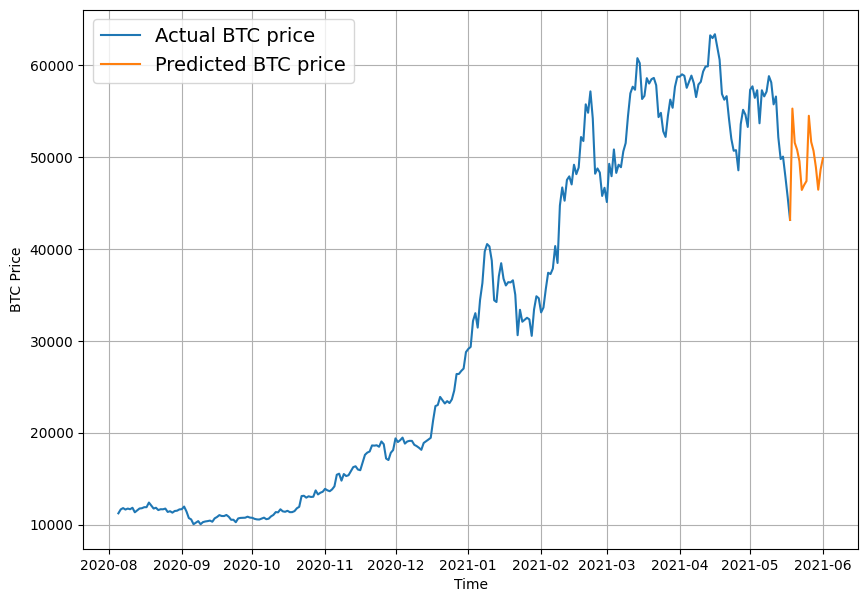

In [136]:
plt.figure(figsize=(10,7))
plot_time_series(bitcoin_prices.index, btc_price, start=2500, format="-", label="Actual BTC price")
plot_time_series(next_time_steps, future_forecast, format="-", label="Predicted BTC price")

# Model 10: turkey problem